# **08 - Hybrid model: structure model + forecasted price index**

Tree models cannot extrapolate a trend beyond the last TRAIN month (see `03_random_forest.ipynb` and `04_gradient_boosting.ipynb`), and a linear time feature extrapolates a past slope. The hybrid separates the two problems:

1. **Detrend.** `y_adj = log1p(target) - log(index_t / 100)`, with the TRAIN-only hedonic index of `07_price_index_forecasting.ipynb` (months 2022-01..2024-12).
2. **Structure model without time.** Ridge or HGB with the static features of `ridge_static` and `hgb_static` (same hyperparameters, loaded from `reports/metrics`), fit on `y_adj`.
3. **Prediction for a TEST month.** `expm1(structure prediction + log(forecast_index_t / 100))`, where the index forecast is made from the TRAIN-only index with the candidate that was selected before 2025 in notebook 07 (naive for Jeonse, drift for Wolse).

**Diagnostic only: oracle variants.** `hybrid_ridge_oracle` and `hybrid_hgb_oracle` replace the forecasted index by the index fitted on all 48 months, which uses TEST information. They are **not valid models** (`valid=False` in the saved metadata) and serve as an upper bound that separates two sources of error: the loss caused by forecasting the index (hybrid minus oracle) and the structure error that remains with a perfect index level (the oracle error itself).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.hybrid import (HybridPredictor, StructureModel, adjust_target, forecast_adjustment, index_adjustment,
                               oracle_index, train_index)
from rent_model.io import save_run
from rent_model.metrics import all_metrics, paired_bootstrap_wape_diff
from rent_model.splits import temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data, indices and reference models

In [2]:
df = load_clean()

def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

data, idx_train, idx_oracle, selected, adj_forecast, adj_oracle, params = {}, {}, {}, {}, {}, {}, {}
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(train=train, test=test, target=spec['target'],
                       X_train=build_features(train, track, include_time=True), y_train=build_target(train, track),
                       X_test=build_features(test, track, include_time=True), y_test=test[spec['target']])
    idx_train[track] = train_index(df, track)
    idx_oracle[track] = oracle_index(df, track)
    report = json.loads((config.METRICS_DIR / f'ts_index_{track}.json').read_text(encoding='utf-8'))
    selected[track] = report['rolling_origin']['selected']
    adj_forecast[track] = forecast_adjustment(idx_train[track], selected[track], horizon=12)
    adj_oracle[track] = pd.Series(idx_oracle[track]['log_coef'].reindex(adj_forecast[track].index).to_numpy(), index=adj_forecast[track].index)
    # consistency with notebook 07: the forecast recomputed here equals the saved one
    saved = [v['mean'] for v in report['forecast_2025_from_train_only'][selected[track]].values()]
    assert np.allclose(100 * np.exp(adj_forecast[track].to_numpy()), saved), 'index forecast differs from ts_index report'
    params[track] = {'ridge': last_run(track, 'ridge_static')['meta']['params'], 'hgb': last_run(track, 'hgb_static')['meta']['params']}
    print(f"{track}: TRAIN-only index ends {idx_train[track].index.max():%Y-%m} at {idx_train[track]['index'].iloc[-1]:.2f}; "
          f"selected index candidate (pre-2025) = {selected[track]}; forecast index 2025-01 = {100 * np.exp(adj_forecast[track].iloc[0]):.2f}, "
          f"2025-12 = {100 * np.exp(adj_forecast[track].iloc[-1]):.2f}; oracle index 2025-01 = {100 * np.exp(adj_oracle[track].iloc[0]):.2f}, "
          f"2025-12 = {100 * np.exp(adj_oracle[track].iloc[-1]):.2f}")
    print(f"   structure params: ridge {params[track]['ridge']} | hgb {params[track]['hgb']}")

jeonse: TRAIN-only index ends 2024-12 at 101.46; selected index candidate (pre-2025) = naive; forecast index 2025-01 = 101.46, 2025-12 = 101.46; oracle index 2025-01 = 100.15, 2025-12 = 103.96
   structure params: ridge {'alpha': 0.01} | hgb {'learning_rate': 0.05, 'max_iter': 1000, 'max_leaf_nodes': 127, 'min_samples_leaf': 10, 'l2_regularization': 1.0}


wolse: TRAIN-only index ends 2024-12 at 94.90; selected index candidate (pre-2025) = drift; forecast index 2025-01 = 94.76, 2025-12 = 93.21; oracle index 2025-01 = 100.62, 2025-12 = 95.28
   structure params: ridge {'alpha': 0.01} | hgb {'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 127, 'min_samples_leaf': 100, 'l2_regularization': 10.0}


## Detrended target

In [3]:
for track in config.TRACKS:
    d = data[track]
    d['y_adj'] = adjust_target(d['y_train'], d['train']['contract_month'], idx_train[track])
    by_year = pd.DataFrame({'log1p_target': d['y_train'].groupby(d['train']['contract_date'].dt.year).mean().to_numpy(),
                            'y_adj': pd.Series(d['y_adj'], index=d['y_train'].index).groupby(d['train']['contract_date'].dt.year).mean().to_numpy()},
                           index=sorted(d['train']['contract_date'].dt.year.unique()))
    print(f"{track}: TRAIN std of log1p(target) = {d['y_train'].std():.4f}, of y_adj = {np.std(d['y_adj'], ddof=1):.4f}")
    display(by_year.T)

jeonse: TRAIN std of log1p(target) = 0.7309, of y_adj = 0.7306


,2022,2023,2024
log1p_target,10.2081,10.2789,10.3529
y_adj,10.2325,10.3411,10.3641


wolse: TRAIN std of log1p(target) = 0.8132, of y_adj = 0.8135


,2022,2023,2024
log1p_target,3.9160,3.9593,3.9253
y_adj,3.9282,3.9652,4.0022


## Fit the structure models and predict 2025

In [4]:
fitted, preds, rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]; months = d['test']['contract_month']
    for kind in ['ridge', 'hgb']:
        structure = StructureModel(kind, params[track][kind]).fit(d['X_train'], d['y_adj'])
        for suffix, adjustment, valid in [('', adj_forecast[track], True), ('_oracle', adj_oracle[track], False)]:
            model_id = f'hybrid_{kind}{suffix}'
            predictor = HybridPredictor(structure, adjustment, valid=valid)
            pred = predictor.predict(d['X_test'], months)
            fitted[(track, model_id)], preds[(track, model_id)] = predictor, pred
            rows.append({'track': track, 'model_id': model_id, 'valid': valid, **all_metrics(d['y_test'].to_numpy(), pred)})
metrics = pd.DataFrame(rows)

REFERENCES = ['ridge_static', 'ridge_time', 'hgb_static', 'hgb_time']
cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[['valid'] + cols].astype({'valid': object})
    table['valid'] = ['yes' if v else 'NO (oracle, diagnostic)' for v in table['valid']]
    for ref_id in REFERENCES:
        run = last_run(track, ref_id)
        table.loc[f'(ref) {ref_id}'] = ['yes (reference)'] + [run[c] for c in cols]
    print(f'TEST metrics - {track}')
    display(table)

TEST metrics - jeonse


,valid,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,,
hybrid_ridge,yes,37935,23.1356,"10,427.3802",17.4033,-4.8006,-8.4734,0.3491,0.7864
hybrid_ridge_oracle,"NO (oracle, diagnostic)",37935,22.8945,"10,318.7237",17.2292,-4.2523,-7.9031,0.3482,0.7875
hybrid_hgb,yes,37935,17.4448,"7,862.4920",12.9598,-3.3505,-5.0263,0.2806,0.8620
hybrid_hgb_oracle,"NO (oracle, diagnostic)",37935,17.2465,"7,773.1458",12.8836,-2.8474,-4.4224,0.2799,0.8627
(ref) ridge_static,yes (reference),37935,24.3664,"10,982.1171",18.6254,-9.2051,-12.7540,0.3537,0.7808
(ref) ridge_time,yes (reference),37935,24.0436,"10,836.6378",18.2974,-8.3812,-11.9167,0.3520,0.7829
(ref) hgb_static,yes (reference),37935,18.5858,"8,376.7595",14.2813,-7.7759,-9.3616,0.2852,0.8575
(ref) hgb_time,yes (reference),37935,17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,0.2817,0.8609


TEST metrics - wolse


,valid,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,,
hybrid_ridge,yes,57829,50.4930,37.8518,39.5737,-19.7210,-28.1816,0.7460,0.2446
hybrid_ridge_oracle,"NO (oracle, diagnostic)",57829,49.3913,37.0259,37.8106,-15.3338,-24.2409,0.7435,0.2497
hybrid_hgb,yes,57829,46.1356,34.5853,36.7523,-19.4932,-25.0701,0.6968,0.3410
hybrid_hgb_oracle,"NO (oracle, diagnostic)",57829,44.8760,33.6411,34.9774,-15.0720,-20.9506,0.6936,0.3470
(ref) ridge_static,yes (reference),57829,49.9662,37.4569,38.7759,-17.5402,-26.1871,0.7447,0.2473
(ref) ridge_time,yes (reference),57829,51.3471,38.4920,40.8782,-22.7534,-30.8606,0.7497,0.2372
(ref) hgb_static,yes (reference),57829,45.5432,34.1412,36.0367,-17.6542,-23.2012,0.6944,0.3454
(ref) hgb_time,yes (reference),57829,45.7417,34.2900,37.3742,-18.2042,-22.4644,0.6973,0.3400


**Interpretation (Jeonse).** The hybrid with a ridge structure model reaches a TEST WAPE of 23.1356%, better than `ridge_time` (24.0436%) and `ridge_static` (24.3664%), and its median bias is -4.8006% against -8.3812% and -9.2051%. The hybrid with an HGB structure model (17.4448%) improves on `hgb_static` (18.5858%) but not on `hgb_time` (17.3111%); its median bias is smaller (-3.3505% against -3.9480%) but its aggregate bias is larger (-5.0263% against -4.0113%). The oracle variants, which are not valid models, give 22.8945% (ridge) and 17.2465% (HGB).

**Interpretation (Wolse).** Here the hybrid does not help: `hybrid_ridge` has a WAPE of 50.4930%, better than `ridge_time` (51.3471%) but worse than `ridge_static` (49.9662%), and `hybrid_hgb` has 46.1356% against 45.7417% for `hgb_time` and 45.5432% for `hgb_static`. The median bias of the hybrids (-19.7210% and -19.4932%) is larger than that of the static models (-17.5402% and -17.6542%). With the oracle index the WAPE would be 49.3913% and 44.8760%, with median biases of -15.3338% and -15.0720%.

## Error decomposition: structure vs index

In [5]:
wape = lambda track, model_id: float(metrics[(metrics['track'] == track) & (metrics['model_id'] == model_id)]['wape_pct'].iloc[0])
bias = lambda track, model_id: float(metrics[(metrics['track'] == track) & (metrics['model_id'] == model_id)]['median_bias_pct'].iloc[0])
rows = []
for track in config.TRACKS:
    for kind in ['ridge', 'hgb']:
        static, time_model = last_run(track, f'{kind}_static'), last_run(track, f'{kind}_time')
        hyb, orc = wape(track, f'hybrid_{kind}'), wape(track, f'hybrid_{kind}_oracle')
        rows.append({'track': track, 'structure': kind,
                     'wape_static': static['wape_pct'], 'wape_time_model': time_model['wape_pct'],
                     'wape_hybrid': hyb, 'wape_oracle(invalid)': orc,
                     'structure_error = oracle': orc, 'index_forecast_loss = hybrid - oracle': hyb - orc,
                     'hybrid - static': hyb - static['wape_pct'], 'oracle - static': orc - static['wape_pct'],
                     'hybrid - time_model': hyb - time_model['wape_pct'],
                     'median_bias_static': static['median_bias_pct'], 'median_bias_hybrid': bias(track, f'hybrid_{kind}'),
                     'median_bias_oracle': bias(track, f'hybrid_{kind}_oracle')})
decomposition = pd.DataFrame(rows).set_index(['track', 'structure'])
display(decomposition.T)

rows = []
for track in config.TRACKS:
    gap = adj_forecast[track] - adj_oracle[track]
    rows.append({'track': track, 'mean log gap (forecast - oracle index)': gap.mean(),
                 'mean gap in index %': (np.exp(gap) - 1).mean() * 100,
                 'largest monthly gap in index %': ((np.exp(gap) - 1) * 100).abs().max()})
display(pd.DataFrame(rows).set_index('track'))

track                                  jeonse            wolse         
structure                               ridge     hgb    ridge      hgb
wape_static                           24.3664 18.5858  49.9662  45.5432
wape_time_model                       24.0436 17.3111  51.3471  45.7417
wape_hybrid                           23.1356 17.4448  50.4930  46.1356
wape_oracle(invalid)                  22.8945 17.2465  49.3913  44.8760
structure_error = oracle              22.8945 17.2465  49.3913  44.8760
index_forecast_loss = hybrid - oracle  0.2411  0.1982   1.1017   1.2596
hybrid - static                       -1.2308 -1.1410   0.5268   0.5924
oracle - static                       -1.4719 -1.3393  -0.5749  -0.6672
hybrid - time_model                   -0.9080  0.1337  -0.8540   0.3939
median_bias_static                    -9.2051 -7.7759 -17.5402 -17.6542
median_bias_hybrid                    -4.8006 -3.3505 -19.7210 -19.4932
median_bias_oracle                    -4.2523 -2.8474 -15.3338 -15.0720

,mean log gap (forecast - oracle index),mean gap in index %,largest monthly gap in index %
track,,,
jeonse,-0.0073,-0.6968,5.4378
wolse,-0.0517,-4.9993,9.3283


**Interpretation.** The table separates two sources of error. In Jeonse the structure error that remains with a perfect index level (the oracle WAPE) is 22.8945% for ridge and 17.2465% for HGB, and forecasting the index adds only 0.2411 and 0.1982 points (hybrid minus oracle); the forecast index recovers most of the attainable gain over the static model (-1.2308 of -1.4719 points for ridge, -1.1410 of -1.3393 for HGB). In Wolse a perfect index would improve on the static models (oracle minus static: -0.5749 and -0.6672 points), but the index forecast loses 1.1017 and 1.2596 points, so the hybrid ends worse than the static models (+0.5268 and +0.5924). The index forecast is the weak link: the mean gap between the forecasted and the oracle index is -0.6968% in Jeonse (largest monthly gap 5.4378%) and -4.9993% in Wolse (largest monthly gap 9.3283%), consistent with the 2025 gaps of notebook 07. Against the time-feature models, the hybrid gains 0.9080 (Jeonse) and 0.8540 (Wolse) points for ridge, and loses 0.1337 and 0.3939 points for HGB.

## Is the hybrid better than the time-feature models? Paired bootstrap on TEST

In [6]:
def reference_predictions(track, model_id):
    ref = pd.read_parquet(config.PREDICTIONS_DIR / f'{track}__{model_id}.parquet')
    assert np.allclose(ref['y_true'].to_numpy(), data[track]['y_test'].to_numpy()), 'reference predictions are not in the same TEST order'
    return ref

comparisons = [('hybrid_ridge', 'ridge_time'), ('hybrid_ridge', 'ridge_static'), ('hybrid_hgb', 'hgb_time'), ('hybrid_hgb', 'hgb_static'),
               ('hybrid_ridge', 'hgb_time'), ('hybrid_hgb', 'ridge_time')]
rows = []
for track in config.TRACKS:
    y_true = data[track]['y_test'].to_numpy()
    for new_id, ref_id in comparisons:
        ref = reference_predictions(track, ref_id)
        boot = paired_bootstrap_wape_diff(y_true, preds[(track, new_id)], ref['y_pred'].to_numpy())
        rows.append({'track': track, 'model': new_id, 'reference': ref_id, 'wape_model': wape(track, new_id),
                     'wape_reference': float(last_run(track, ref_id)['wape_pct']), 'delta_pts': boot['diff'], 'boot_se': boot['se'],
                     'ci95_low': boot['ci_low'], 'ci95_high': boot['ci_high'], 'better_than_noise': bool(boot['ci_high'] < 0)})
deltas = pd.DataFrame(rows).set_index(['track', 'model', 'reference'])
display(deltas)

wape_model  wape_reference  delta_pts  boot_se  ci95_low  ci95_high  better_than_noise
track  model        reference                                                                                           
jeonse hybrid_ridge ridge_time       23.1356         24.0436    -0.9080   0.0193   -0.9465    -0.8716               True
                    ridge_static     23.1356         24.3664    -1.2308   0.0225   -1.2747    -1.1849               True
       hybrid_hgb   hgb_time         17.4448         17.3111     0.1337   0.0487    0.0362     0.2277              False
                    hgb_static       17.4448         18.5858    -1.1410   0.0331   -1.2033    -1.0755               True
       hybrid_ridge hgb_time         23.1356         17.3111     5.8245   0.1006    5.6324     6.0145              False
       hybrid_hgb   ridge_time       17.4448         24.0436    -6.5988   0.1036   -6.8003    -6.4030               True
wolse  hybrid_ridge ridge_time       50.4930         51.3471    -0.8540   0.0113   -0.8763    -0.8325               True
                    ridge_static     50.4930         49.9662     0.5268   0.0082    0.5112     0.5429              False
       hybrid_hgb   hgb_time         46.1356         45.7417     0.3939   0.0603    0.2712     0.5020              False
                    hgb_static       46.1356         45.5432     0.5924   0.0177    0.5579     0.6266              False
       hybrid_ridge hgb_time         50.4930         45.7417     4.7513   0.1356    4.4888     4.9956              False
       hybrid_hgb   ridge_time       46.1356         51.3471    -5.2114   0.1097   -5.4253    -4.9985               True

**Interpretation.** The hybrid improves on `ridge_time` by more than the bootstrap noise in both tracks: -0.9080 points in Jeonse (standard error 0.0193, interval -0.9465 to -0.8716) and -0.8540 in Wolse (standard error 0.0113, interval -0.8763 to -0.8325). With HGB it does not: `hybrid_hgb` is worse than `hgb_time` by +0.1337 points in Jeonse (interval 0.0362 to 0.2277) and by +0.3939 in Wolse (interval 0.2712 to 0.5020). Against the static models, the hybrid improves in Jeonse (-1.2308 for ridge and -1.1410 for HGB, both intervals below zero) and is worse in Wolse (+0.5268 and +0.5924). The ridge hybrid does not reach the boosting models (+5.8245 points against `hgb_time` in Jeonse and +4.7513 in Wolse).

## Monthly predicted vs actual, 2025

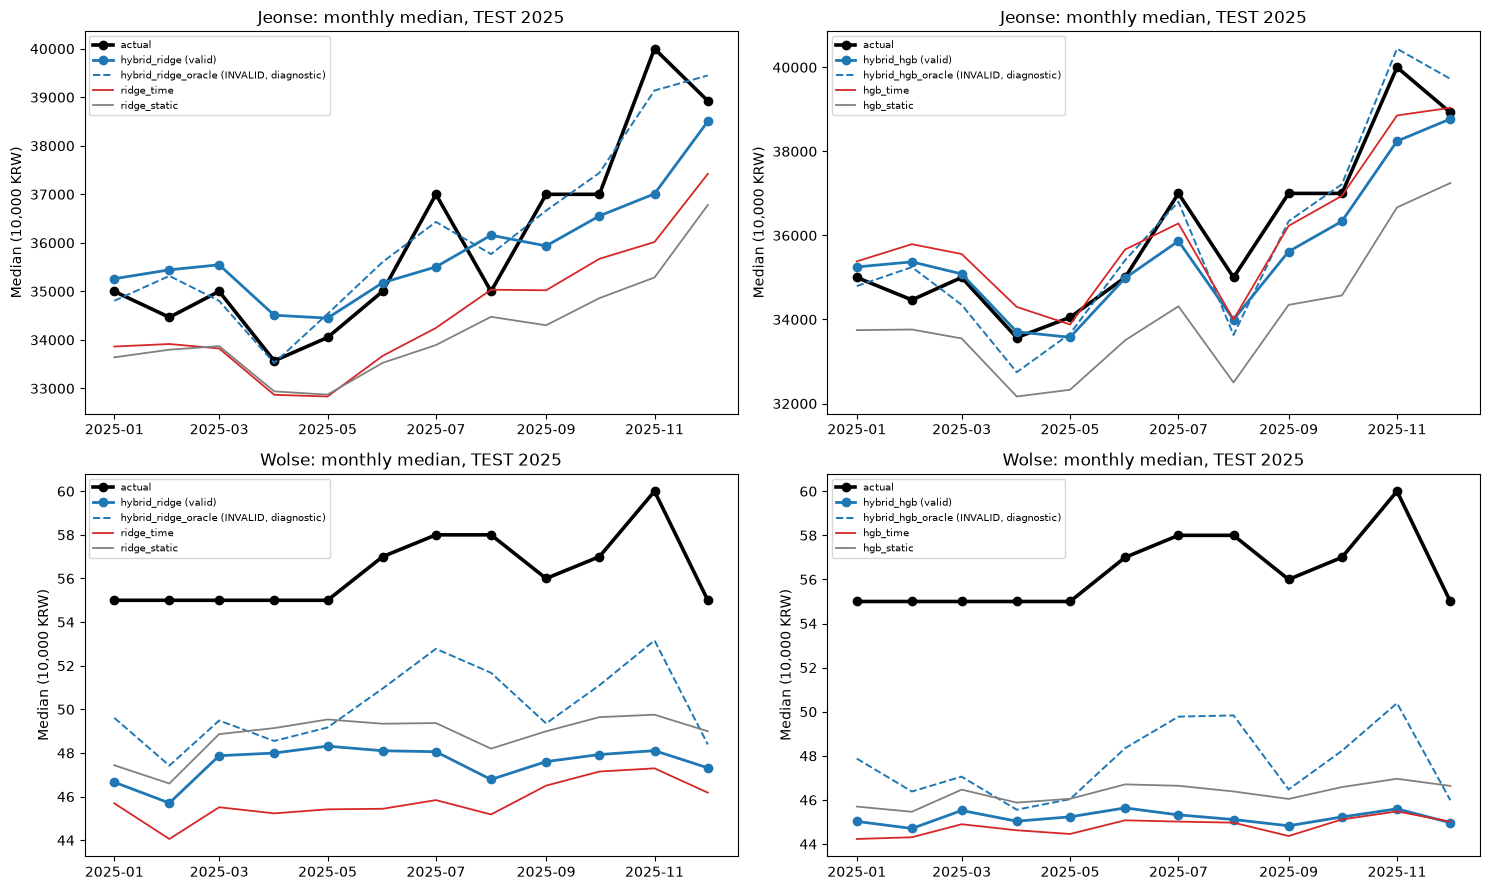

('jeonse', 'ridge')


,actual,hybrid_ridge,hybrid_ridge_oracle,ridge_static,ridge_time
contract_date,,,,,
2025-01-01,"35,000.0000","35,260.7200","34,806.3800","33,641.1300","33,863.3200"
2025-02-01,"34,466.0000","35,443.7400","35,318.6200","33,798.1200","33,915.3100"
2025-03-01,"35,000.0000","35,547.9300","34,804.0100","33,871.7700","33,823.6800"
2025-04-01,"33,569.0000","34,508.5400","33,524.0100","32,939.3000","32,868.8600"
2025-05-01,"34,050.0000","34,448.9900","34,536.1000","32,872.7300","32,833.8000"
2025-06-01,"35,000.0000","35,177.9600","35,605.0500","33,526.8500","33,670.7600"
2025-07-01,"37,000.0000","35,504.5800","36,430.8900","33,893.8600","34,247.0200"
2025-08-01,"35,000.0000","36,156.5800","35,767.0500","34,475.9800","35,033.7700"
2025-09-01,"37,000.0000","35,936.7700","36,664.2600","34,301.6100","35,022.6700"


('jeonse', 'hgb')


,actual,hybrid_hgb,hybrid_hgb_oracle,hgb_static,hgb_time
contract_date,,,,,
2025-01-01,"35,000.0000","35,249.8900","34,795.6900","33,746.2200","35,382.9300"
2025-02-01,"34,466.0000","35,371.1500","35,246.2800","33,761.8800","35,791.8200"
2025-03-01,"35,000.0000","35,084.3600","34,350.1300","33,548.9600","35,558.2300"
2025-04-01,"33,569.0000","33,707.2300","32,745.5600","32,167.7200","34,299.1500"
2025-05-01,"34,050.0000","33,576.2600","33,661.1600","32,327.7400","33,880.5400"
2025-06-01,"35,000.0000","34,986.0600","35,410.8200","33,505.3200","35,664.8100"
2025-07-01,"37,000.0000","35,865.5200","36,801.2500","34,313.4000","36,285.8300"
2025-08-01,"35,000.0000","33,999.0700","33,632.7800","32,500.7000","34,000.3200"
2025-09-01,"37,000.0000","35,617.6200","36,338.6500","34,347.5400","36,227.2500"


('wolse', 'ridge')


,actual,hybrid_ridge,hybrid_ridge_oracle,ridge_static,ridge_time
contract_date,,,,,
2025-01-01,55.0000,46.6600,49.6100,47.4400,45.6900
2025-02-01,55.0000,45.7100,47.4200,46.6000,44.0600
2025-03-01,55.0000,47.8800,49.4900,48.8700,45.5100
2025-04-01,55.0000,48.0000,48.5500,49.1400,45.2300
2025-05-01,55.0000,48.3100,49.1700,49.5400,45.4200
2025-06-01,57.0000,48.1000,50.9500,49.3400,45.4400
2025-07-01,58.0000,48.0600,52.7800,49.3700,45.8400
2025-08-01,58.0000,46.7800,51.6800,48.2000,45.1800
2025-09-01,56.0000,47.6000,49.3500,49.0000,46.5000


('wolse', 'hgb')


,actual,hybrid_hgb,hybrid_hgb_oracle,hgb_static,hgb_time
contract_date,,,,,
2025-01-01,55.0000,45.0300,47.8800,45.7000,44.2300
2025-02-01,55.0000,44.7100,46.3900,45.4700,44.3100
2025-03-01,55.0000,45.5200,47.0600,46.4700,44.9000
2025-04-01,55.0000,45.0400,45.5600,45.8800,44.6300
2025-05-01,55.0000,45.2400,46.0400,46.0500,44.4600
2025-06-01,57.0000,45.6400,48.3500,46.7100,45.0800
2025-07-01,58.0000,45.3200,49.7800,46.6500,45.0200
2025-08-01,58.0000,45.1100,49.8300,46.3900,44.9700
2025-09-01,56.0000,44.8300,46.4800,46.0500,44.3700


In [7]:
month = lambda frame: frame['contract_date'].dt.to_period('M').dt.to_timestamp()
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
monthly = {}
for r, track in enumerate(config.TRACKS):
    d = data[track]; test = d['test']
    actual = d['y_test'].groupby(month(test)).median()
    for c, kind in enumerate(['ridge', 'hgb']):
        table = pd.DataFrame({'actual': actual})
        for model_id in [f'hybrid_{kind}', f'hybrid_{kind}_oracle']:
            table[model_id] = pd.Series(preds[(track, model_id)], index=test.index).groupby(month(test)).median()
        for ref_id in [f'{kind}_static', f'{kind}_time']:
            ref = reference_predictions(track, ref_id)
            table[ref_id] = ref.groupby(month(ref))['y_pred'].median()
        monthly[(track, kind)] = table
        ax = axes[r, c]
        ax.plot(table.index, table['actual'], color='black', lw=2.6, marker='o', label='actual')
        ax.plot(table.index, table[f'hybrid_{kind}'], color='tab:blue', lw=2, marker='o', label=f'hybrid_{kind} (valid)')
        ax.plot(table.index, table[f'hybrid_{kind}_oracle'], color='tab:blue', lw=1.4, ls='--', label=f'hybrid_{kind}_oracle (INVALID, diagnostic)')
        ax.plot(table.index, table[f'{kind}_time'], color='tab:red', lw=1.3, label=f'{kind}_time')
        ax.plot(table.index, table[f'{kind}_static'], color='gray', lw=1.3, label=f'{kind}_static')
        ax.set_title(f'{track.capitalize()}: monthly median, TEST 2025'); ax.set_ylabel('Median (10,000 KRW)'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '08_hybrid_monthly_2025.png', dpi=130); plt.show()
for key, table in monthly.items():
    print(key); display(table.round(2))

**Interpretation.** In Jeonse the HGB hybrid follows the first half of 2025 closely (for example 35,250 against 35,000 in January and 34,986 against 35,000 in June) and lags in the second half, where the forecasted index is flat: in November the actual median is 40,000 against 38,243 for the hybrid and 40,442 for the invalid oracle. In Wolse every model stays well below the actual median (55.0000 to 60.0000): the HGB hybrid predicts between 44.7100 and 45.6400 and the oracle between 45.5600 and 50.3900, so even a perfect index level leaves a large gap in the monthly median.

## Bias by quarter (TEST 2025)

In [8]:
def quarter_bias(track, series_by_model, kind):
    y = data[track]['y_test'].to_numpy(); q = data[track]['test']['contract_date'].dt.quarter.to_numpy()
    out = {}
    for model_id, p in series_by_model.items():
        frame = pd.DataFrame({'y': y, 'p': p, 'q': q})
        if kind == 'median':
            out[model_id] = frame.groupby('q').apply(lambda g: np.median((g['p'] - g['y']) / g['y']) * 100, include_groups=False)
        else:
            out[model_id] = frame.groupby('q').apply(lambda g: (g['p'].sum() - g['y'].sum()) / g['y'].sum() * 100, include_groups=False)
    return pd.DataFrame(out)

for track in config.TRACKS:
    models = {m: preds[(track, m)] for m in ['hybrid_ridge', 'hybrid_ridge_oracle', 'hybrid_hgb', 'hybrid_hgb_oracle']}
    for ref_id in ['ridge_static', 'ridge_time', 'hgb_static', 'hgb_time']:
        models[ref_id] = reference_predictions(track, ref_id)['y_pred'].to_numpy()
    print(f'{track}: median bias % by quarter'); display(quarter_bias(track, models, 'median'))
    print(f'{track}: aggregate bias % by quarter'); display(quarter_bias(track, models, 'aggregate'))

jeonse: median bias % by quarter


,hybrid_ridge,hybrid_ridge_oracle,hybrid_hgb,hybrid_hgb_oracle,ridge_static,ridge_time,hgb_static,hgb_time
q,,,,,,,,
1,-2.9427,-4.0686,-1.5588,-2.7035,-7.3712,-7.1413,-6.1271,-2.1899
2,-3.5033,-3.9889,-2.3645,-2.9078,-7.9533,-7.8145,-6.7014,-2.6684
3,-5.1895,-3.9351,-3.8728,-2.6402,-9.5715,-8.1154,-8.0948,-4.4908
4,-8.4203,-5.0944,-6.5858,-3.1472,-12.6368,-10.8194,-10.7661,-6.8928


jeonse: aggregate bias % by quarter


,hybrid_ridge,hybrid_ridge_oracle,hybrid_hgb,hybrid_hgb_oracle,ridge_static,ridge_time,hgb_static,hgb_time
q,,,,,,,,
1,-5.6817,-6.8811,-2.3550,-3.5951,-10.1096,-9.8781,-6.8294,-1.3390
2,-7.5310,-7.9513,-4.0358,-4.4631,-11.8544,-11.7616,-8.4179,-2.8731
3,-8.9583,-7.8516,-5.6476,-4.4880,-13.2079,-11.7862,-9.9655,-4.6600
4,-12.3173,-9.1112,-8.6363,-5.2840,-16.4087,-14.6394,-12.7733,-7.7599


wolse: median bias % by quarter


,hybrid_ridge,hybrid_ridge_oracle,hybrid_hgb,hybrid_hgb_oracle,ridge_static,ridge_time,hgb_static,hgb_time
q,,,,,,,,
1,-18.7884,-15.1294,-17.6575,-13.8332,-17.0410,-21.6447,-16.1005,-16.6934
2,-18.1739,-15.8371,-18.8356,-16.3448,-16.1093,-22.9208,-17.0888,-17.3754
3,-21.4501,-14.9698,-21.5659,-15.2255,-19.1303,-24.3519,-19.5333,-20.4067
4,-20.7231,-15.2954,-20.7378,-15.2314,-18.0298,-22.2650,-18.3676,-19.0530


wolse: aggregate bias % by quarter


,hybrid_ridge,hybrid_ridge_oracle,hybrid_hgb,hybrid_hgb_oracle,ridge_static,ridge_time,hgb_static,hgb_time
q,,,,,,,,
1,-25.1276,-21.8183,-22.0951,-18.6511,-23.5335,-27.7648,-20.6206,-20.0219
2,-27.7635,-25.6020,-25.0154,-22.7632,-25.8931,-31.9446,-23.3094,-22.5286
3,-30.0952,-24.4199,-27.4227,-21.5233,-27.9685,-32.5375,-25.4731,-24.6740
4,-30.0061,-25.3123,-25.8940,-20.9229,-27.5593,-31.3150,-23.4772,-22.7011


**Interpretation.** In Jeonse the median bias of `hybrid_ridge` grows in absolute value through 2025, from -2.9427% in Q1 to -8.4203% in Q4 (aggregate from -5.6817% to -12.3173%), while the oracle stays between -3.9351% and -5.0944%: the forecasted index is flat at the end-2024 level and the actual index rises. `hybrid_hgb` follows the same pattern (-1.5588% in Q1, -6.5858% in Q4) and its median bias is closer to zero than that of both `hgb_static` and `hgb_time` in every quarter, while its aggregate bias is larger than that of `hgb_time` (for example -8.6363% against -7.7599% in Q4). In Wolse all hybrids underpredict in every quarter (median bias between -17.6575% and -21.5659%), and the oracle variants reduce the bias to between -13.8332% and -16.3448%.

## Save runs

In [9]:
for track in config.TRACKS:
    d = data[track]
    for kind in ['ridge', 'hgb']:
        for suffix in ['', '_oracle']:
            model_id = f'hybrid_{kind}{suffix}'
            predictor = fitted[(track, model_id)]
            meta = predictor.meta(
                structure=kind, structure_params=params[track][kind], structure_features='static features, no time feature',
                target='y_adj = log1p(target) - log(index_t / 100), TRAIN-only hedonic index',
                index_candidate=selected[track] if not suffix else 'oracle hedonic index fitted on all 48 months',
                index_2025_first=float(100 * np.exp((adj_forecast[track] if not suffix else adj_oracle[track]).iloc[0])),
                index_2025_last=float(100 * np.exp((adj_forecast[track] if not suffix else adj_oracle[track]).iloc[-1])),
                fit_period='2022-01-01..2024-12-31', eval_period='2025')
            if suffix:
                meta['note'] = 'INVALID as a model: the index is fitted with 2025 data. Diagnostic upper bound for the error decomposition.'
            save_run(track, model_id, d['y_test'], preds[(track, model_id)], meta=meta,
                     context=d['test'][['district_name', 'contract_date']])
print('Saved', 4 * len(config.TRACKS), 'runs; oracle runs flagged valid=False')

Saved 8 runs; oracle runs flagged valid=False


## Summary

In [10]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct', 'aggregate_bias_pct'])
display(summary)

wape_pct         median_bias_pct          aggregate_bias_pct         
track                 jeonse   wolse          jeonse    wolse             jeonse    wolse
model_id                                                                                 
hybrid_hgb           17.4448 46.1356         -3.3505 -19.4932            -5.0263 -25.0701
hybrid_hgb_oracle    17.2465 44.8760         -2.8474 -15.0720            -4.4224 -20.9506
hybrid_ridge         23.1356 50.4930         -4.8006 -19.7210            -8.4734 -28.1816
hybrid_ridge_oracle  22.8945 49.3913         -4.2523 -15.3338            -7.9031 -24.2409

## Conclusion

- **Against the time-feature models.** The hybrid beats `ridge_time` in both tracks (23.1356% against 24.0436% in Jeonse, 50.4930% against 51.3471% in Wolse) but does not beat `hgb_time` (17.4448% against 17.3111% in Jeonse, 46.1356% against 45.7417% in Wolse).
- **Against the static models.** It improves them in Jeonse (ridge 24.3664% to 23.1356%, HGB 18.5858% to 17.4448%) and makes them worse in Wolse (49.9662% to 50.4930%, 45.5432% to 46.1356%).
- **Where the error is.** With a perfect index (invalid oracle) the WAPE would be 22.8945% and 17.2465% in Jeonse and 49.3913% and 44.8760% in Wolse, so the possible gain from the index is modest and depends on forecasting it well; the index forecast loses between 0.1982 and 1.2596 points. The oracle values must not be read as achievable performance.